# Exploratory Data Analysis — Loan Approval Prediction

This notebook explores the raw loan application data before any cleaning takes place. The goal is to understand data quality issues, the shape of the target variable, and which features look predictive of loan approval so that later preprocessing and modeling decisions are grounded in evidence rather than guesswork.

In [1]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/AnaNicuesa/loan-approval-prediction.git"
PROJECT_PATH = Path("/content/loan-approval-prediction")

if IN_COLAB:
    if not PROJECT_PATH.exists():
        !git clone -q {REPO_URL}

    os.chdir(PROJECT_PATH)

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

print("Current directory:", Path.cwd())
print("src exists:", (Path.cwd() / "src").exists())

Current directory: /content/loan-approval-prediction
src exists: True


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.preprocessing import parse_dependents
from src.utils import RAW_DATA_PATH, FIGURES_DIR, ensure_directories

ensure_directories()
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

print("Setup completed.")

Setup completed.


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.preprocessing import parse_dependents
from src.utils import RAW_DATA_PATH, FIGURES_DIR, ensure_directories

ensure_directories()
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

## 1. Loading the data

In [4]:
df = pd.read_csv(RAW_DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (563, 13)


,loan_id,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
0,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,0.0
1,LP001005,Male,Yes,0,Graduate,NaN,3000.0,0.0,66.0,360.0,1.0,Urban,1.0
2,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,1.0
3,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,1.0
4,LP001011,Male,Yes,2,Graduate,Yes,5417.0,4196.0,267.0,360.0,1.0,Urban,1.0


## 2. Overview

Thirteen columns: a loan identifier, eleven applicant/loan attributes, and the target `loan_status`. Everything except the numeric income and loan fields is stored as `object`, which is expected given the raw survey-style source of this data.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 563 entries, 0 to 562
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             534 non-null    object 
 1   gender              534 non-null    object 
 2   married             544 non-null    object 
 3   dependents          531 non-null    object 
 4   education           541 non-null    object 
 5   self_employed       529 non-null    object 
 6   applicant_income    537 non-null    float64
 7   coapplicant_income  529 non-null    float64
 8   loan_amount         533 non-null    float64
 9   loan_amount_term    535 non-null    float64
 10  credit_history      541 non-null    float64
 11  property_area       542 non-null    object 
 12  loan_status         535 non-null    float64
dtypes: float64(6), object(7)
memory usage: 57.3+ KB


In [6]:
dtype_summary = df.dtypes.value_counts()
dtype_summary

,count
object,7
float64,6


## 3. Missing values

Every column contains missing values, including the target variable. Using dropna() on the entire dataset would remove too many rows, so a different strategy will be needed. The percentage of missing values is low and fairly similar across columns (around 3–6%).

In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary

,missing_count,missing_pct
self_employed,34,6.04
coapplicant_income,34,6.04
dependents,32,5.68
loan_amount,30,5.33
loan_id,29,5.15
gender,29,5.15
loan_amount_term,28,4.97
loan_status,28,4.97
applicant_income,26,4.62
credit_history,22,3.91


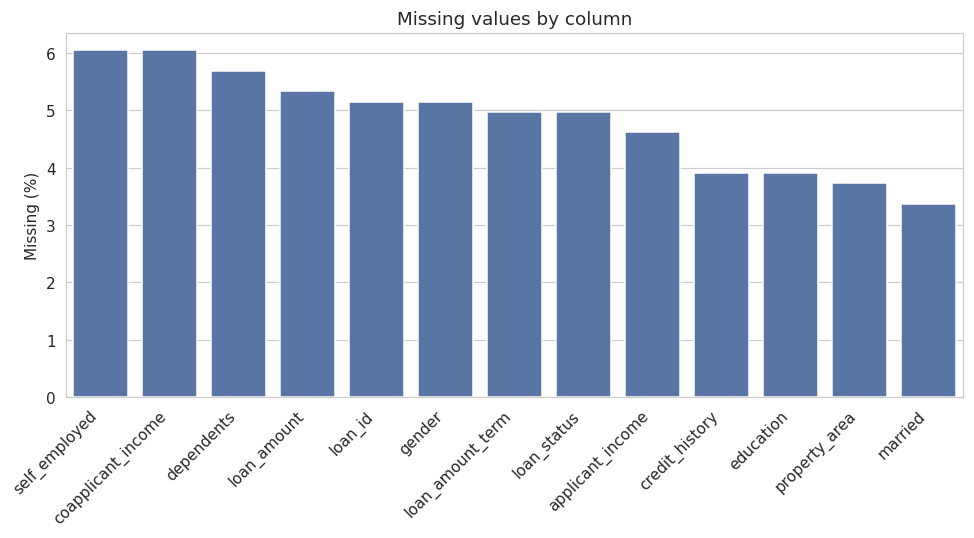

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=missing_summary.index, y=missing_summary["missing_pct"], color="#4C72B0", ax=ax)
ax.set_ylabel("Missing (%)")
ax.set_xlabel("")
ax.set_title("Missing values by column")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "missing_values.png")
plt.show()

## 4. Duplicates
The dataset contains 25 exact duplicate rows and 50 repeated loan_id values. The exact duplicates will be removed during preprocessing, and the repeated loan IDs will be investigated before preparing the data for modeling.


In [9]:
exact_duplicates = df.duplicated().sum()
duplicate_ids = df["loan_id"].duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicates}")
print(f"Duplicate loan_id values: {duplicate_ids}")

Exact duplicate rows: 25
Duplicate loan_id values: 50


## 5. Descriptive statistics

In [10]:
df.describe()

,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,loan_status
count,537.000000,529.000000,533.000000,535.000000,541.000000,535.000000
mean,5379.370577,1692.604764,147.433396,341.674766,0.878004,0.717757
std,6064.809533,3093.379309,85.851735,65.301425,0.327584,0.450512
min,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000
25%,2894.000000,0.000000,100.000000,360.000000,1.000000,0.000000
50%,3762.000000,1250.000000,128.000000,360.000000,1.000000,1.000000
75%,5818.000000,2333.000000,172.000000,360.000000,1.000000,1.000000
max,81000.000000,41667.000000,650.000000,480.000000,1.000000,1.000000


The numerical variables show a wide range of values. Applicant income varies considerably, with some very high values compared to the median, suggesting the presence of outliers. Most loans have a term of 360 months, and the majority of applicants have a positive credit history. The target variable is also imbalanced, with approved loans (loan_status = 1) being more common than rejected loans.

In [11]:
categorical_cols = ["gender", "married", "dependents", "education", "self_employed", "property_area"]
for col in categorical_cols:
    print(df[col].value_counts(dropna=False))
    print()

gender
Male      433
Female    101
NaN        29
Name: count, dtype: int64

married
Yes    348
No     196
NaN     19
Name: count, dtype: int64

dependents
0      307
1       93
2       88
3+      43
NaN     32
Name: count, dtype: int64

education
Graduate        426
Not Graduate    115
NaN              22
Name: count, dtype: int64

self_employed
No     461
Yes     68
NaN     34
Name: count, dtype: int64

property_area
Semiurban    212
Urban        175
Rural        155
NaN           21
Name: count, dtype: int64



Most applicants are male, married, graduates, and not self-employed. The property_area variable is relatively balanced across rural, urban, and semiurban locations. Several categorical variables contain a small number of missing values, which will need to be addressed during preprocessing.

## 6. Target analysis

Rows with a missing target (loan_status) cannot be used for training, so they will be removed during preprocessing. Among the remaining observations, approved loans are more common than rejected loans, indicating a moderate class imbalance.
￼




loan_status
Approved    0.717757
Rejected    0.282243
Name: proportion, dtype: float64


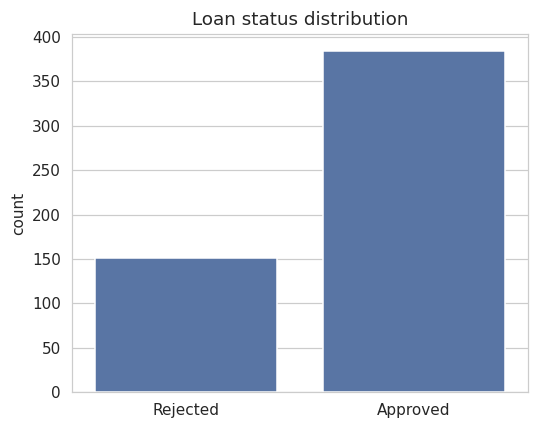

In [12]:
df_labeled = df.dropna(subset=["loan_status"]).copy()
df_labeled["loan_status"] = df_labeled["loan_status"].astype(int)

target_counts = df_labeled["loan_status"].value_counts(normalize=True).rename({0: "Rejected", 1: "Approved"})
print(target_counts)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=df_labeled["loan_status"].map({0: "Rejected", 1: "Approved"}), color="#4C72B0", ax=ax)
ax.set_xlabel("")
ax.set_title("Loan status distribution")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "target_distribution.png")
plt.show()

## 7. Distributions of numeric features
Applicant and coapplicant income are heavily right-skewed, with a handful of extreme values (one applicant reports an income of over 80,000, compared with a median of around 3,800). Loan amount follows a similar pattern. These outliers are worth keeping rather than removing, as they appear to represent genuine high-income applicants rather than data entry errors.


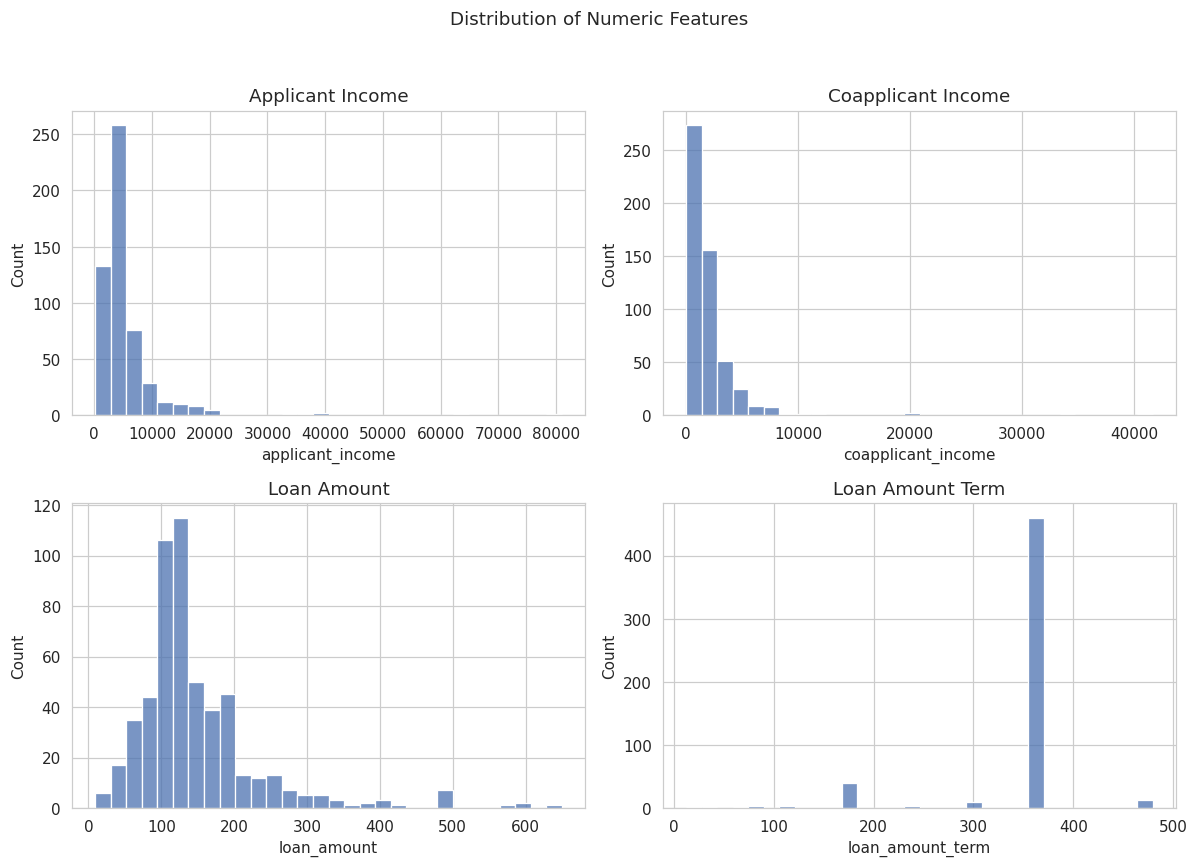

In [13]:
numeric_cols = ["applicant_income", "coapplicant_income", "loan_amount", "loan_amount_term"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col].dropna(), bins=30, color="#4C72B0", ax=ax)
    ax.set_title(col.replace("_", " ").title())
fig.suptitle("Distribution of Numeric Features")
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIGURES_DIR / "numeric_distributions.png")
plt.show()

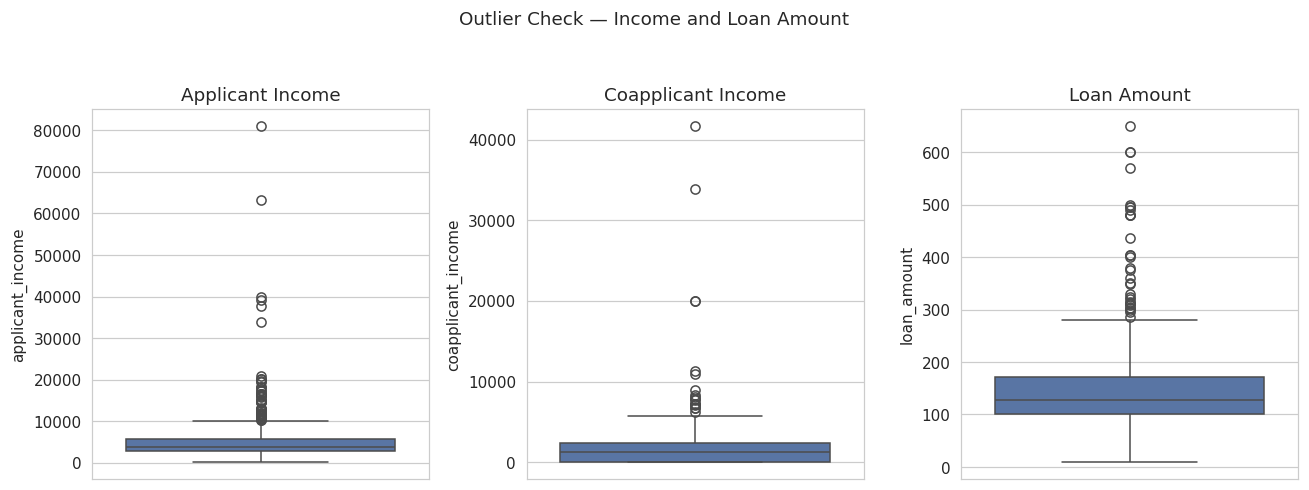

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
for ax, col in zip(axes, ["applicant_income", "coapplicant_income", "loan_amount"]):
    sns.boxplot(y=df[col].dropna(), color="#4C72B0", ax=ax)
    ax.set_title(col.replace("_", " ").title())
fig.suptitle("Outlier Check — Income and Loan Amount")
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIGURES_DIR / "numeric_boxplots.png")
plt.show()

The boxplots reveal numerous high-value outliers in applicant income, coapplicant income, and loan amount. Most observations are concentrated within a relatively narrow range, while a small number of observations lie well above the upper whisker.

## 8. Categorical features against the target

Credit history stands out immediately: applicants with a positive credit history are approved roughly 80% of the time, versus about 11% for those without one. Property area and marital status show smaller but visible gaps — semiurban applicants and married applicants are approved somewhat more often than their counterparts.

In [15]:
df.shape

(563, 13)

In [16]:
df_labeled = df.dropna(subset=["loan_status"])

print(df_labeled.shape)

(535, 13)


In [17]:
df_labeled

,loan_id,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
0,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,0.0
1,LP001005,Male,Yes,0,Graduate,NaN,3000.0,0.0,66.0,360.0,1.0,Urban,1.0
2,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,1.0
3,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,1.0
4,LP001011,Male,Yes,2,Graduate,Yes,5417.0,4196.0,267.0,360.0,1.0,Urban,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
557,LP001819,Male,Yes,1,Not Graduate,No,6608.0,0.0,137.0,180.0,1.0,Urban,1.0
559,NaN,NaN,Yes,0,Graduate,No,2483.0,2466.0,90.0,180.0,0.0,Rural,1.0
560,LP001977,Male,Yes,1,Graduate,No,1625.0,1803.0,96.0,360.0,1.0,Urban,1.0
561,NaN,Male,Yes,1,Graduate,No,NaN,1843.0,123.0,NaN,1.0,Semiurban,1.0


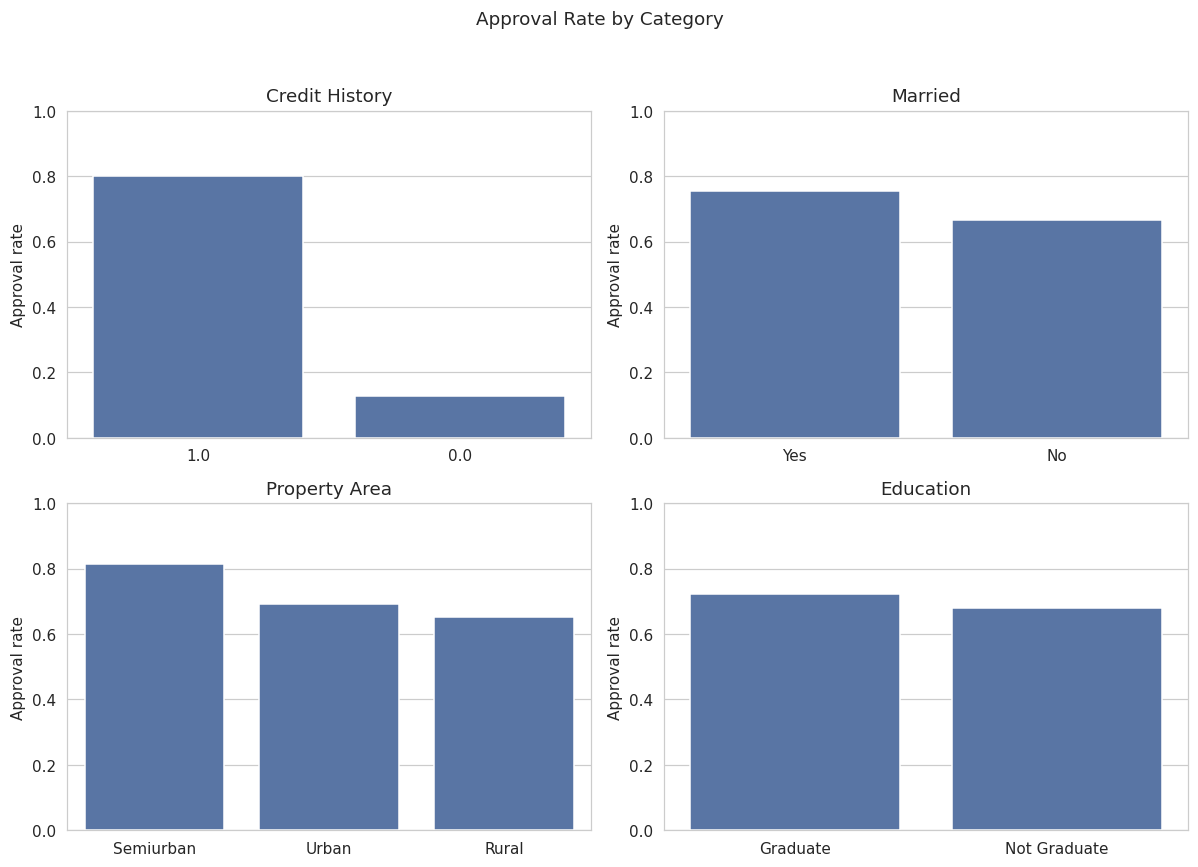

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_cols = ["credit_history", "married", "property_area", "education"]
for ax, col in zip(axes.flatten(), plot_cols):
    rates = df_labeled.groupby(col)["loan_status"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.index.astype(str), y=rates.values, color="#4C72B0", ax=ax)
    ax.set_ylabel("Approval rate")
    ax.set_xlabel("")
    ax.set_title(col.replace("_", " ").title())
    ax.set_ylim(0, 1)
fig.suptitle("Approval Rate by Category")
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIGURES_DIR / "approval_rate_by_category.png")
plt.show()

## 9. Correlation analysis
The correlation matrix shows that most numerical variables have weak linear relationships. The strongest correlation with the target variable is observed for credit_history (0.48), suggesting that applicants with a positive credit history are more likely to have their loans approved. A moderate positive correlation is also observed between applicant_income and loan_amount (0.54), indicating that higher-income applicants tend to request larger loans. No evidence of strong multicollinearity is observed among the numerical predictors.


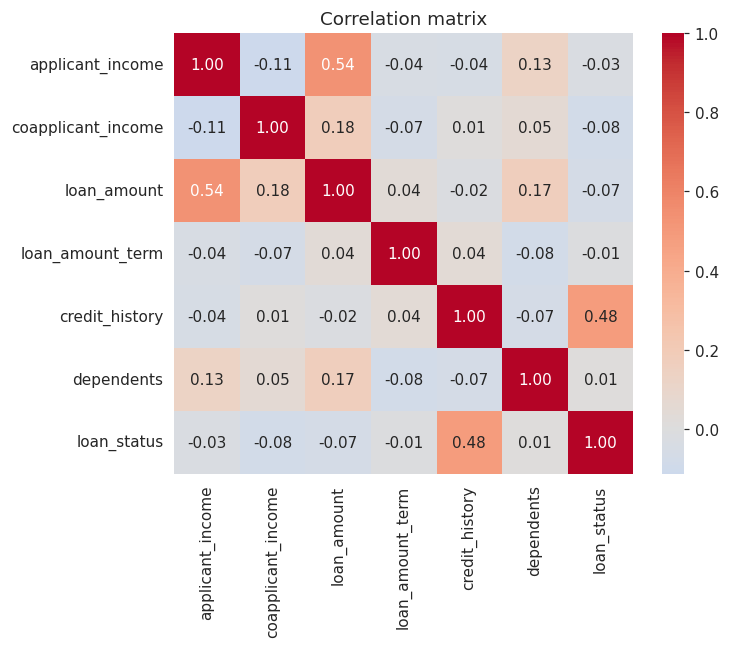

In [19]:
df_corr = df_labeled.copy()
df_corr["dependents"] = parse_dependents(df_corr["dependents"])

corr_cols = ["applicant_income", "coapplicant_income", "loan_amount", "loan_amount_term",
             "credit_history", "dependents", "loan_status"]
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_heatmap.png")
plt.show()

## 10. Conclusions

- The target is missing in a small number of rows and cannot be used for supervised learning, so those observations will be excluded rather than imputed.
- Missing values are present in nearly every column but at relatively low rates (3–6%), suggesting that simple imputation is likely to be sufficient during preprocessing.
- The dataset contains exact duplicate rows and repeated loan IDs that should be investigated and handled before model training.
- Applicant income, coapplicant income, and loan amount contain several high-value outliers that appear plausible rather than erroneous, so they are retained rather than removed.
- The target variable is moderately imbalanced, with approved loans accounting for about 71% of the labeled observations. This class distribution should be taken into account during model development and evaluation.
- `credit_history` appears to be the strongest predictor of loan approval, based on both the approval-rate analysis and its moderate positive correlation with the target.
- Most numerical variables show weak linear relationships with one another and with the target, suggesting that additional feature engineering may help improve predictive performance.


These findings provide a clear basis for the data cleaning and preprocessing steps carried out in `02_Data_Preprocessing.ipynb`.